<a href="https://colab.research.google.com/github/amanpoonia/Research_project_Prof.Nour/blob/main/Chartisme_v01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#tickerlist = ['EURUSD=X','GSPC']
ticker = ['EURUSD=X']
end_date = dt.datetime(2022,12,31)
start_date = dt.datetime(2003,12,1)

In [6]:
data = yf.download(ticker, start_date, end_date)

/tmp/ipykernel_3293/2688127335.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


In [7]:
prices = data['Close']
prices

Ticker,EURUSD=X
Date,
2003-12-01,1.196501
2003-12-02,1.208897
2003-12-03,1.212298
2003-12-04,1.208094
2003-12-05,1.218695
...,...
2022-12-26,1.066780
2022-12-27,1.064022
2022-12-28,1.063717


In [8]:
returns = prices.pct_change()

In [9]:
log_returns = np.log(1+returns)
log_returns

Ticker,EURUSD=X
Date,
2003-12-01,NaN
2003-12-02,0.010307
2003-12-03,0.002809
2003-12-04,-0.003473
2003-12-05,0.008736
...,...
2022-12-26,0.006062
2022-12-27,-0.002589
2022-12-28,-0.000287


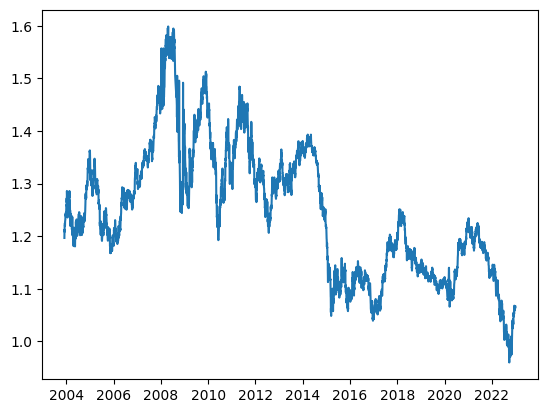

In [10]:
plt.plot(prices)

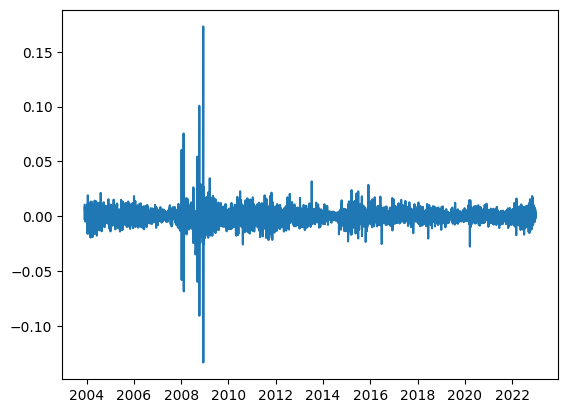

In [11]:
plt.plot(returns)

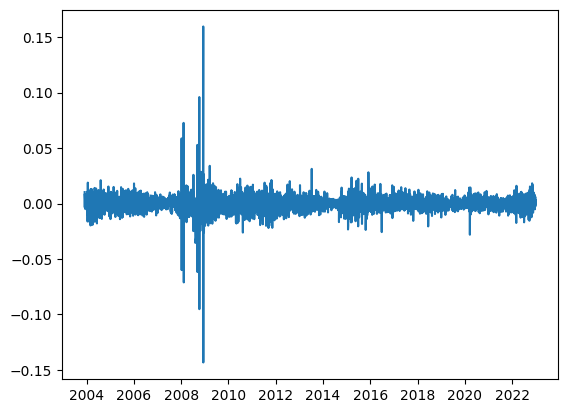

In [12]:
plt.plot(log_returns)

In [15]:
lower = log_returns.quantile(0.30)
upper = log_returns.quantile(0.70)

In [31]:
log_returns_categorized = log_returns.copy()
conditions = [
    log_returns_categorized['EURUSD=X'] < lower['EURUSD=X'],
    log_returns_categorized['EURUSD=X'] > upper['EURUSD=X']
]
choices = [-1, 1]
log_returns_categorized['category'] = np.select(conditions, choices, default=0)
display(log_returns_categorized.head(20))

Ticker,EURUSD=X,category
Date,,
2003-12-01,NaN,0
2003-12-02,0.010307,1
2003-12-03,0.002809,1
2003-12-04,-0.003473,-1
2003-12-05,0.008736,1
2003-12-08,0.002709,1
2003-12-09,0.002447,0
2003-12-10,-0.004827,-1
2003-12-11,0.002710,1


In [34]:
log_returns_categorized1 = log_returns_categorized.dropna()
log_returns_categorized1

Ticker,EURUSD=X,category
Date,,
2003-12-02,0.010307,1
2003-12-03,0.002809,1
2003-12-04,-0.003473,-1
2003-12-05,0.008736,1
2003-12-08,0.002709,1
...,...,...
2022-12-26,0.006062,1
2022-12-27,-0.002589,-1
2022-12-28,-0.000287,0


In [35]:
log_returns_categorized

Ticker,EURUSD=X,category
Date,,
2003-12-01,NaN,0
2003-12-02,0.010307,1
2003-12-03,0.002809,1
2003-12-04,-0.003473,-1
2003-12-05,0.008736,1
...,...,...
2022-12-26,0.006062,1
2022-12-27,-0.002589,-1
2022-12-28,-0.000287,0


In [40]:
log_returns_categorized1['transition_neg1_to_neg1'] = ((log_returns_categorized1['category'].shift(1) == -1) & (log_returns_categorized1['category'] == -1)).astype(int)
display(log_returns_categorized1.head(50))

/tmp/ipykernel_3293/3183523235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  log_returns_categorized1['transition_neg1_to_neg1'] = ((log_returns_categorized1['category'].shift(1) == -1) & (log_returns_categorized1['category'] == -1)).astype(int)


Ticker,EURUSD=X,category,transition_neg1_to_neg1
Date,,,
2003-12-02,0.010307,1,0
2003-12-03,0.002809,1,0
2003-12-04,-0.003473,-1,0
2003-12-05,0.008736,1,0
2003-12-08,0.002709,1,0
2003-12-09,0.002447,0,0
2003-12-10,-0.004827,-1,0
2003-12-11,0.002710,1,0
2003-12-12,0.004484,1,0


In [46]:
sumnegtoneg = int(log_returns_categorized1['transition_neg1_to_neg1'].sum())

In [44]:
sumnegtoneg

426

In [51]:
sumnegtoall = log_returns_categorized1[log_returns_categorized1['category']==-1]

In [75]:
vvv = log_returns_categorized1[log_returns_categorized1['transition_neg1_to_neg1']==1]

In [52]:
sumnegtoall

Ticker,EURUSD=X,category,transition_neg1_to_neg1
Date,,,
2003-12-04,-0.003473,-1,0
2003-12-10,-0.004827,-1,0
2003-12-19,-0.003064,-1,0
2004-01-07,-0.006315,-1,0
2004-01-12,-0.009216,-1,0
...,...,...,...
2022-12-07,-0.002663,-1,1
2022-12-12,-0.003552,-1,0
2022-12-16,-0.003357,-1,0


In [60]:
negtoneg_return = log_returns_categorized1[log_returns_categorized1['transition_neg1_to_neg1']==1]
exc_ret = negtoneg_return.sum()
negtoneg_return.head(50)
exc_ret

,0
Ticker,
EURUSD=X,-2.977132
category,-426.000000
transition_neg1_to_neg1,426.000000


In [77]:
a = vvv['EURUSD=X'].sum()
a1 = round(a,4)
a1

np.float64(-2.9771)

In [54]:
excess_return = sumnegtoall['EURUSD=X'].sum()
excess_return

np.float64(-0.11541779230993397)

In [53]:
negtoneg = 426/1485
negtoneg

0.2868686868686869

In [79]:
a2 = a1/426
a2

np.float64(-0.00698849765258216)

In [14]:
l_ret_lower = log_returns[log_returns < lower]
l_ret_lower

Ticker,EURUSD=X
Date,
2003-12-01,NaN
2003-12-02,NaN
2003-12-03,NaN
2003-12-04,-0.003473
2003-12-05,NaN
...,...
2022-12-26,NaN
2022-12-27,-0.002589
2022-12-28,NaN


In [55]:
log_returns_categorized1['transition_neg1_to_neg1'].sum()

np.int64(426)

In [16]:
l_ret_upper = log_returns[log_returns > upper]
l_ret_upper

Ticker,EURUSD=X
Date,
2003-12-01,NaN
2003-12-02,0.010307
2003-12-03,0.002809
2003-12-04,NaN
2003-12-05,0.008736
...,...
2022-12-26,0.006062
2022-12-27,NaN
2022-12-28,NaN


In [17]:
l_ret_middle = log_returns[(log_returns > lower) & (log_returns < upper)]
l_ret_middle

Ticker,EURUSD=X
Date,
2003-12-01,NaN
2003-12-02,NaN
2003-12-03,NaN
2003-12-04,NaN
2003-12-05,NaN
...,...
2022-12-26,NaN
2022-12-27,NaN
2022-12-28,-0.000287


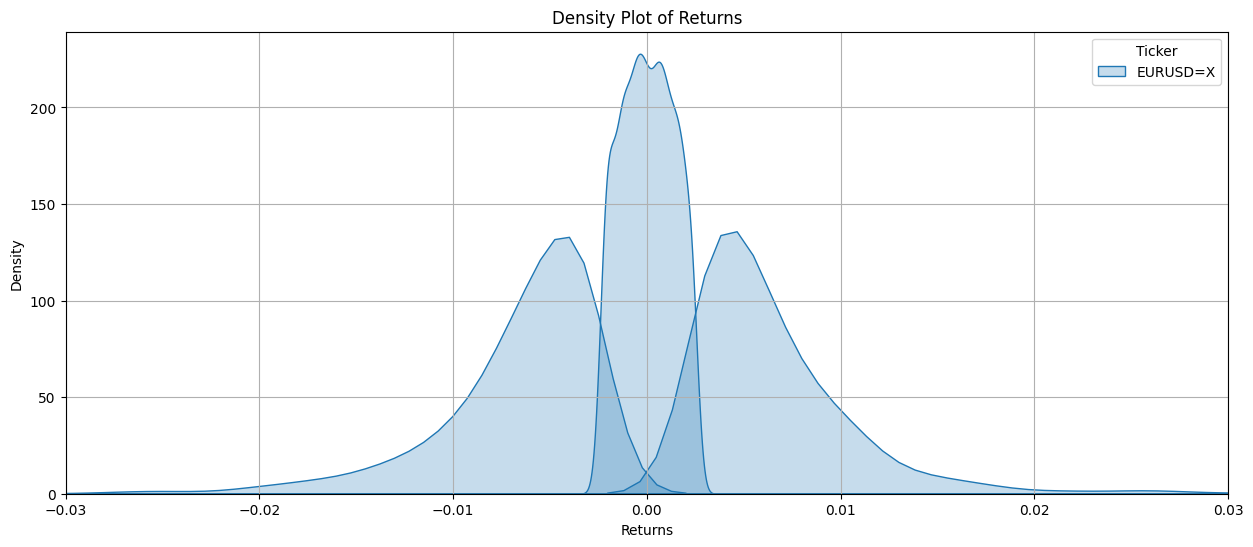

In [20]:
plt.figure(figsize=(15, 6))
sns.kdeplot(l_ret_upper.dropna(), fill=True)
sns.kdeplot(l_ret_lower.dropna(), fill=True)
sns.kdeplot(l_ret_middle.dropna(), fill=True)
plt.title('Density Plot of Returns')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.grid(True)
plt.xlim(-0.03, 0.03)
plt.show()

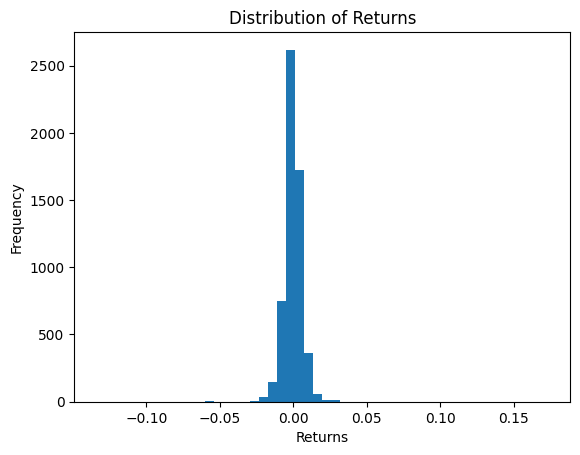

In [12]:
plt.hist(returns, bins=50)
plt.title('Distribution of Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

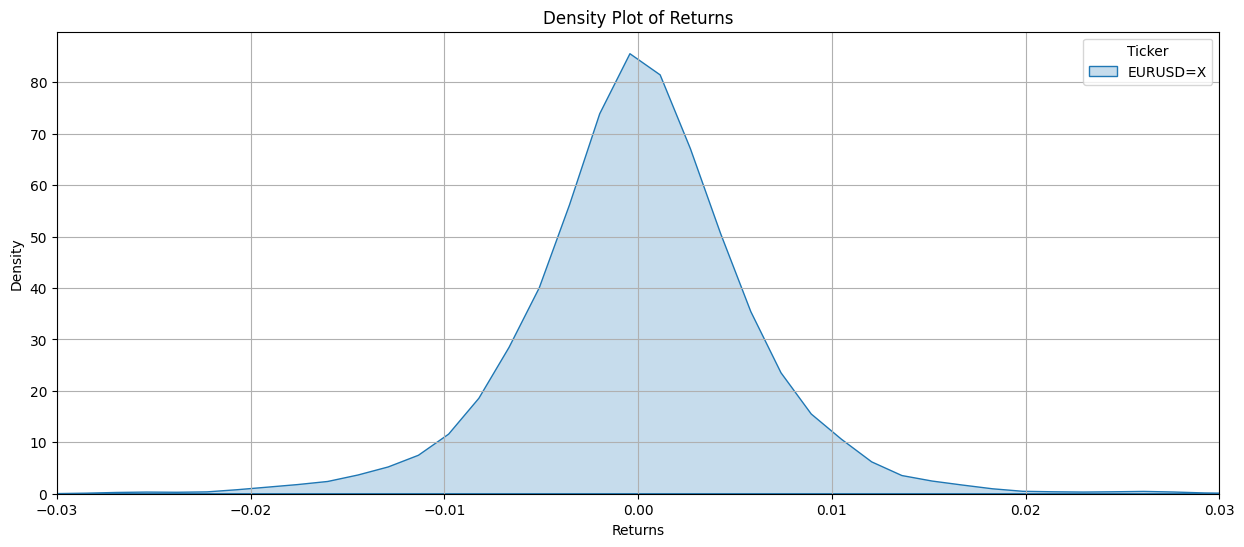

In [16]:
plt.figure(figsize=(15, 6))
sns.kdeplot(log_returns.dropna(), fill=True)
plt.title('Density Plot of Returns')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.grid(True)
plt.xlim(-0.03, 0.03)
plt.show()

### Conditional Distribution of Returns

To see a conditional distribution, we can divide our data based on a certain condition and then visualize the distribution for each group. For example, let's look at the distribution of returns conditioned on whether the return was positive or negative.

In [ ]:
# Create conditions for positive and negative returns
positive_returns = returns[returns['EURUSD=X'] > 0].dropna()
negative_returns = returns[returns['EURUSD=X'] <= 0].dropna()

plt.figure(figsize=(12, 7))

sns.kdeplot(positive_returns, fill=True, label='Positive Returns', color='green')
sns.kdeplot(negative_returns, fill=True, label='Negative Returns', color='red')

plt.title('Conditional Density Plot of Returns (Positive vs. Negative)')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.xlim(-0.03, 0.03) # Keep the same x-axis limits for comparison
plt.show()

In [ ]:
lower_quantile = returns.quantile(0.30)
print(f"The 30% lower quantile of returns is: {lower_quantile}")

In [28]:
returns2 = returns.dropna()
returns2['state'] = np.where(returns2['EURUSD=X'] < 0, -1, 1)
display(returns2.head())

/tmp/ipykernel_3293/1308636784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  returns2['state'] = -1


Ticker,EURUSD=X,state
Date,,
2003-12-02,0.010360,-1
2003-12-03,0.002813,-1
2003-12-04,-0.003467,-1
2003-12-05,0.008775,-1
2003-12-08,0.002713,-1
